# Voxelwise factor loading comparisons

Compare factor × 26-scalar loading vectors across:
- **CSF mask:** `all/with_csf` vs `all/no_csf`
- **Parcellation:** voxelwise (`all/with_csf` and `all/no_csf`) vs regionwise (`All4_Combined`)
- **Cohorts:** `all`, `hcpya`, `hcpaging`, `penn_controls` (4×4 matrices per mask)

Sections below run separately for **factors-3** and **factors-4**. Each figure uses three factor-specific panels in order: **Overall**, **Non-Gaussian**, **Anisotropic** (F2, F3, F1). Points are colored by reconstruction model. Factor order/sign is aligned to the `all` reference (per mask) via Hungarian matching on |r| between loading rows, with sign flip when r < 0. The voxelwise vs regionwise comparison uses 3-factor loadings only (regionwise `All4_Combined` is 3-factor).


In [22]:
from __future__ import annotations

from pathlib import Path
from typing import Dict, List, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch
from scipy.optimize import linear_sum_assignment

plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Georgia"]
plt.rcParams["font.size"] = 14

BASE_DIR = Path("__PROJECT_ROOT__")
RUN_DIR = BASE_DIR / "derivatives/analysis/factor_analysis_voxelwise/Voxelwise_ReducedControls"
FIG_DIR = BASE_DIR / "derivatives/analysis/factor_analysis_voxelwise/figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

GROUPS = ["all", "hcpya", "hcpaging", "penn_controls"]
GROUP_DISPLAY = {
    "all": "All controls",
    "hcpya": "HCP-YA",
    "hcpaging": "HCP-Aging",
    "penn_controls": "Penn controls",
}
MASKS = ["with_csf", "no_csf"]
MASK_DISPLAY = {
    "with_csf": "With CSF voxels",
    "no_csf": "Without CSF voxels",
}
FACTOR_CONFIGS = [("factors-3", 3), ("factors-4", 4)]
FILE_PREFIX = "controls_Voxelwise_ReducedControls"
REGIONWISE_DIR = BASE_DIR / "derivatives/analysis/factor_analysis/All4_Combined"
REGIONWISE_LOADINGS_NAME = "controls_All4_Combined_scalar_factor_loadings.csv"
REGIONWISE_N_FACTORS = 3

# Subplot order: Overall (F2), Non-Gaussian (F3), Anisotropic (F1)
NAMED_FACTORS: List[Tuple[str, int]] = [
    ("Overall", 1),
    ("Non-Gaussian", 2),
    ("Anisotropic", 0),
]

LABEL_FONTSIZE = 16
GROUP_LABEL_FONTSIZE = 10
TICK_FONTSIZE = 13
ANNOT_FONTSIZE = 14
CSF_LABEL_FONTSIZE = 20
CSF_TICK_FONTSIZE = 16
CSF_LEGEND_FONTSIZE = 15
PANEL_TITLE_FONTSIZE = 18
SCATTER_PANEL_TITLE_FONTSIZE = 24

RECONSTRUCTION_MODELS: List[Tuple[str, str, str]] = [
    ("#38489E", "NODDI", "noddi"),
    ("#289144", "MAP-MRI", "map"),
    ("#7A297F", "DKI", "dki"),
    ("#C43031", "DTI", "dti"),
    ("#FAA51A", "GQI", "gqi"),
]
CBAR_LABEL = r"Pearson's $r$ of factor loadings"

SCALAR_COLUMNS: List[str] | None = None


In [23]:
def regionwise_loadings_path() -> Path:
    return REGIONWISE_DIR / REGIONWISE_LOADINGS_NAME


def loadings_path(group: str, mask: str, factor_subdir: str) -> Path:
    return (
        RUN_DIR
        / group
        / mask
        / factor_subdir
        / f"{FILE_PREFIX}_{group}_{mask}_scalar_factor_loadings.csv"
    )


def load_loadings(path: Path, n_factors: int) -> np.ndarray:
    global SCALAR_COLUMNS
    df = pd.read_csv(path, index_col=0)
    expected_rows = [f"F{i + 1}" for i in range(n_factors)]
    if list(df.index) != expected_rows:
        raise ValueError(f"Unexpected factor rows in {path}: {list(df.index)}")
    if SCALAR_COLUMNS is None:
        SCALAR_COLUMNS = list(df.columns)
    elif list(df.columns) != SCALAR_COLUMNS:
        raise ValueError(f"Scalar column mismatch in {path}")
    return df.to_numpy(dtype=float)


def factor_correlation_matrix(ref: np.ndarray, target: np.ndarray) -> np.ndarray:
    corr = np.full((ref.shape[0], target.shape[0]), np.nan, dtype=float)
    for i in range(ref.shape[0]):
        for j in range(target.shape[0]):
            a, b = ref[i], target[j]
            if np.std(a) > 0 and np.std(b) > 0:
                corr[i, j] = np.corrcoef(a, b)[0, 1]
    return corr


def match_factors_to_reference(
    ref: np.ndarray,
    target: np.ndarray,
) -> Tuple[np.ndarray, List[int], List[int]]:
    corr = factor_correlation_matrix(ref, target)
    cost = -np.abs(np.nan_to_num(corr, nan=0.0))
    ref_idx, target_idx = linear_sum_assignment(cost)
    aligned = np.zeros_like(ref)
    perm = []
    signs = []
    for i, j in zip(ref_idx, target_idx):
        r = corr[i, j]
        sign = 1 if (np.isfinite(r) and r >= 0) else -1
        aligned[i] = sign * target[j]
        perm.append(int(j))
        signs.append(sign)
    return aligned, perm, signs


def vectorize_loadings(loadings: np.ndarray) -> np.ndarray:
    return loadings.reshape(-1)


def loading_vector_correlation(a: np.ndarray, b: np.ndarray) -> float:
    return float(np.corrcoef(a, b)[0, 1])


def correlation_matrix(vectors: Dict[str, np.ndarray], labels: List[str]) -> pd.DataFrame:
    n = len(labels)
    mat = np.eye(n, dtype=float)
    for i in range(n):
        for j in range(i + 1, n):
            r = loading_vector_correlation(vectors[labels[i]], vectors[labels[j]])
            mat[i, j] = r
            mat[j, i] = r
    return pd.DataFrame(mat, index=labels, columns=labels)


In [24]:
def align_all_groups(factor_subdir: str, n_factors: int) -> Tuple[Dict, Dict]:
    vectors: Dict[str, Dict[str, np.ndarray]] = {mask: {} for mask in MASKS}
    match_info: Dict[str, Dict[str, dict]] = {mask: {} for mask in MASKS}

    for mask in MASKS:
        ref_path = loadings_path("all", mask, factor_subdir)
        ref = load_loadings(ref_path, n_factors)
        vectors[mask]["all"] = vectorize_loadings(ref)
        match_info[mask]["all"] = {
            "perm": list(range(n_factors)),
            "signs": [1] * n_factors,
            "anchor": str(ref_path),
            "loadings": ref,
        }

        for group in GROUPS:
            if group == "all":
                continue
            path = loadings_path(group, mask, factor_subdir)
            raw = load_loadings(path, n_factors)
            aligned, perm, signs = match_factors_to_reference(ref, raw)
            vectors[mask][group] = vectorize_loadings(aligned)
            match_info[mask][group] = {
                "perm": perm,
                "signs": signs,
                "source": str(path),
                "loadings": aligned,
                "row_corr_to_ref": [
                    float(np.corrcoef(ref[i], aligned[i])[0, 1]) for i in range(n_factors)
                ],
            }
    return vectors, match_info


def scalar_indices_for_model(prefix: str) -> List[int]:
    return [i for i, name in enumerate(SCALAR_COLUMNS) if name.startswith(f"{prefix}_")]


def factor_loading_correlation(a_row: np.ndarray, b_row: np.ndarray) -> float:
    return float(np.corrcoef(a_row, b_row)[0, 1])


def top_loadings(loadings_row: np.ndarray, n: int = 3) -> List[Tuple[str, float]]:
    idx = np.argsort(np.abs(loadings_row))[::-1][:n]
    return [(SCALAR_COLUMNS[i], float(loadings_row[i])) for i in idx]


def format_top_loadings(loadings_row: np.ndarray, n: int = 3) -> str:
    return ", ".join(f"{name} ({value:+.3f})" for name, value in top_loadings(loadings_row, n))


def _scatter_axis_limits(*arrays: np.ndarray, pad: float = 0.05) -> Tuple[float, float]:
    vals = np.concatenate([arr.reshape(-1) for arr in arrays])
    lo, hi = float(vals.min()), float(vals.max())
    span = hi - lo
    if span == 0:
        span = max(abs(lo), 1.0) * 0.1
    return lo - pad * span, hi + pad * span


def _annot_text_color(value: float) -> str:
    return "white" if abs(value) > 0.55 else "0.15"


def _plot_model_scatter(
    ax,
    x_row: np.ndarray,
    y_row: np.ndarray,
    *,
    point_size: float = 64,
    edge_lw: float = 0.4,
) -> None:
    for color, _, prefix in RECONSTRUCTION_MODELS:
        idx = scalar_indices_for_model(prefix)
        if not idx:
            continue
        ax.scatter(
            x_row[idx],
            y_row[idx],
            c=color,
            marker="o",
            s=point_size,
            alpha=0.9,
            edgecolors="white",
            linewidths=edge_lw,
            zorder=3,
        )


def save_model_legend() -> None:
    handles = [
        Patch(facecolor=color, edgecolor="none", label=label)
        for color, label, _ in RECONSTRUCTION_MODELS
    ]
    fig, ax = plt.subplots(figsize=(5.5, 1.4))
    ax.axis("off")
    ax.legend(
        handles=handles,
        loc="center",
        ncol=len(handles),
        fontsize=CSF_LEGEND_FONTSIZE,
        frameon=False,
    )
    out_path = FIG_DIR / "loading_scatter_model_legend.png"
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.close(fig)
    print(f"Saved: {out_path}")


def print_factor_correlations_and_top_loadings(
    label: str,
    ref_loadings: np.ndarray,
    target_loadings: np.ndarray,
    *,
    ref_name: str,
    target_name: str,
) -> Dict[str, float]:
    print(f"\n{label}")
    rs: Dict[str, float] = {}
    for name, fi in NAMED_FACTORS:
        x_row = ref_loadings[fi]
        y_row = target_loadings[fi]
        r = factor_loading_correlation(x_row, y_row)
        rs[name] = r
        print(f"  {name}: r = {r:.3f}")
        print(f"    {ref_name} top loadings: {format_top_loadings(x_row)}")
        print(f"    {target_name} top loadings: {format_top_loadings(y_row)}")
    return rs


def plot_loading_pair_scatter(
    x_loadings: np.ndarray,
    y_loadings: np.ndarray,
    *,
    xlabel: str,
    ylabel: str,
    out_path: Path,
    comparison_label: str,
    ref_name: str,
    target_name: str,
) -> Dict[str, float]:
    print_factor_correlations_and_top_loadings(
        comparison_label,
        x_loadings,
        y_loadings,
        ref_name=ref_name,
        target_name=target_name,
    )

    n_panels = len(NAMED_FACTORS)
    fig, axes = plt.subplots(1, n_panels, figsize=(7.0 * n_panels, 7.0), squeeze=False)
    axes = axes[0]

    for ax, (factor_name, fi) in zip(axes, NAMED_FACTORS):
        x_row = x_loadings[fi]
        y_row = y_loadings[fi]
        _plot_model_scatter(ax, x_row, y_row, point_size=64)
        lims = _scatter_axis_limits(x_row, y_row)
        ax.plot(lims, lims, "k--", linewidth=1.0, alpha=0.65, zorder=1)
        ax.set_xlim(lims)
        ax.set_ylim(lims)
        ax.set_title(factor_name, fontsize=SCATTER_PANEL_TITLE_FONTSIZE)
        ax.set_xlabel(xlabel, fontsize=CSF_LABEL_FONTSIZE)
        ax.tick_params(axis="both", labelsize=CSF_TICK_FONTSIZE)
        ax.set_aspect("equal", adjustable="box")

    axes[0].set_ylabel(ylabel, fontsize=CSF_LABEL_FONTSIZE)
    fig.tight_layout()
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out_path}")
    return {
        name: factor_loading_correlation(x_loadings[fi], y_loadings[fi])
        for name, fi in NAMED_FACTORS
    }


def plot_csf_scatter(factor_subdir: str, n_factors: int) -> Dict[str, float]:
    ref_with = load_loadings(loadings_path("all", "with_csf", factor_subdir), n_factors)
    raw_no = load_loadings(loadings_path("all", "no_csf", factor_subdir), n_factors)
    aligned_no, perm, signs = match_factors_to_reference(ref_with, raw_no)
    rs = plot_loading_pair_scatter(
        ref_with,
        aligned_no,
        xlabel="Including CSF in voxel-wise\n correlation-based factor loadings",
        ylabel="Excluding CSF in voxel-wise\n correlation-based factor loadings",
        out_path=FIG_DIR / f"{factor_subdir}_all_with_csf_vs_no_csf_loadings_scatter.png",
        comparison_label=f"{factor_subdir}: with CSF vs without CSF (all controls)",
        ref_name="with CSF",
        target_name="without CSF (aligned)",
    )
    print(f"CSF alignment perm={perm}, signs={signs}")
    return rs


def plot_voxelwise_vs_regionwise_scatter(
    factor_subdir: str, n_factors: int, mask: str
) -> Dict[str, float] | None:
    if n_factors != REGIONWISE_N_FACTORS:
        print(
            f"Skipping voxelwise vs regionwise for {factor_subdir} ({mask}): "
            f"regionwise All4_Combined has {REGIONWISE_N_FACTORS} factors only"
        )
        return None

    voxel_ref = load_loadings(loadings_path("all", mask, factor_subdir), n_factors)
    region_raw = load_loadings(regionwise_loadings_path(), n_factors)
    aligned_region, perm, signs = match_factors_to_reference(voxel_ref, region_raw)
    rs = plot_loading_pair_scatter(
        voxel_ref,
        aligned_region,
        xlabel="Voxel-wise correlation-based\n factor loadings",
        ylabel="Region-wise correlation-based\n factor loadings",
        out_path=FIG_DIR / f"{factor_subdir}_voxelwise_{mask}_vs_regionwise_loadings_scatter.png",
        comparison_label=(
            f"{factor_subdir}: voxelwise ({MASK_DISPLAY[mask]}) vs regionwise (all controls)"
        ),
        ref_name=f"voxelwise ({MASK_DISPLAY[mask]})",
        target_name="regionwise (aligned)",
    )
    print(f"Voxelwise vs regionwise ({mask}) alignment perm={perm}, signs={signs}")
    return rs


def plot_voxelwise_vs_regionwise_scatters(
    factor_subdir: str, n_factors: int
) -> None:
    for mask in MASKS:
        plot_voxelwise_vs_regionwise_scatter(factor_subdir, n_factors, mask)


def print_group_factor_correlations(
    vectors: Dict[str, Dict[str, np.ndarray]], mask: str, n_factors: int
) -> None:
    print(f"\nGroup loading correlations ({MASK_DISPLAY[mask]}):")
    for factor_name, fi in NAMED_FACTORS:
        print(f"  {factor_name}:")
        for i, gi in enumerate(GROUPS):
            for j, gj in enumerate(GROUPS):
                if i >= j:
                    continue
                vi = vectors[mask][gi].reshape(n_factors, len(SCALAR_COLUMNS))[fi]
                vj = vectors[mask][gj].reshape(n_factors, len(SCALAR_COLUMNS))[fi]
                r = factor_loading_correlation(vi, vj)
                print(
                    f"    {GROUP_DISPLAY[gi]} vs {GROUP_DISPLAY[gj]}: r = {r:.3f}"
                )


def plot_group_correlation_matrix(
    vectors: Dict[str, Dict[str, np.ndarray]],
    factor_subdir: str,
    mask: str,
    n_factors: int,
) -> None:
    from matplotlib.gridspec import GridSpec

    n_groups = len(GROUPS)
    n_panels = len(NAMED_FACTORS)
    display_labels = [GROUP_DISPLAY[g] for g in GROUPS]
    cmap = plt.get_cmap("coolwarm")
    norm = plt.Normalize(vmin=-1.0, vmax=1.0)

    print_group_factor_correlations(vectors, mask, n_factors)

    cell_size = 1.25
    panel_side = cell_size * n_groups
    cbar_width = 0.35
    panel_gap = 0.45
    label_margin = 0.55
    fig = plt.figure(
        figsize=(
            panel_side * n_panels + cbar_width + panel_gap * (n_panels - 1),
            panel_side + label_margin,
        )
    )
    gs_outer = GridSpec(
        1,
        n_panels + 1,
        figure=fig,
        width_ratios=[n_groups] * n_panels + [0.35],
        wspace=panel_gap / panel_side,
    )

    for panel_idx, (factor_name, fi) in enumerate(NAMED_FACTORS):
        gs_inner = gs_outer[panel_idx].subgridspec(
            n_groups,
            n_groups,
            width_ratios=[1.0] * n_groups,
            height_ratios=[1.0] * n_groups,
            wspace=0.06,
            hspace=0.06,
        )
        for i in range(n_groups):
            for j in range(n_groups):
                ax = fig.add_subplot(gs_inner[i, j])
                gi, gj = GROUPS[i], GROUPS[j]
                vi_all = vectors[mask][gi].reshape(n_factors, len(SCALAR_COLUMNS))
                vj_all = vectors[mask][gj].reshape(n_factors, len(SCALAR_COLUMNS))
                vi = vi_all[fi]
                vj = vj_all[fi]

                if i == j:
                    ax.set_facecolor(cmap(norm(1.0)))
                    ax.set_xlim(0, 1)
                    ax.set_ylim(0, 1)
                    ax.text(
                        0.5,
                        0.5,
                        "1.000",
                        transform=ax.transAxes,
                        ha="center",
                        va="center",
                        fontsize=ANNOT_FONTSIZE,
                        color=_annot_text_color(1.0),
                    )
                elif i > j:
                    r = factor_loading_correlation(vi, vj)
                    ax.set_facecolor(cmap(norm(r)))
                    ax.set_xlim(0, 1)
                    ax.set_ylim(0, 1)
                    ax.text(
                        0.5,
                        0.5,
                        f"{r:.3f}",
                        transform=ax.transAxes,
                        ha="center",
                        va="center",
                        fontsize=ANNOT_FONTSIZE,
                        color=_annot_text_color(r),
                    )
                else:
                    _plot_model_scatter(ax, vj, vi, point_size=22, edge_lw=0.25)
                    lims = _scatter_axis_limits(vi, vj)
                    ax.plot(lims, lims, "k--", linewidth=0.7, alpha=0.55, zorder=1)
                    ax.set_xlim(lims)
                    ax.set_ylim(lims)

                ax.set_aspect("equal", adjustable="box")
                ax.set_box_aspect(1)
                ax.set_xticks([])
                ax.set_yticks([])
                for spine in ax.spines.values():
                    spine.set_visible(False)

                if i == n_groups - 1:
                    ax.set_xlabel(
                        display_labels[j],
                        fontsize=GROUP_LABEL_FONTSIZE,
                        labelpad=3,
                    )
                if j == 0:
                    ax.set_ylabel(
                        display_labels[i],
                        fontsize=GROUP_LABEL_FONTSIZE,
                        rotation=90,
                        labelpad=4,
                    )

        panel_pos = gs_outer[panel_idx].get_position(fig)
        fig.text(
            panel_pos.x0 + panel_pos.width / 2,
            panel_pos.y1 + 0.02,
            factor_name,
            ha="center",
            va="bottom",
            fontsize=PANEL_TITLE_FONTSIZE,
        )

    cax = fig.add_subplot(gs_outer[n_panels])
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=cax)
    cbar.set_label(CBAR_LABEL, fontsize=LABEL_FONTSIZE)
    cbar.ax.tick_params(labelsize=TICK_FONTSIZE)

    fig.suptitle(MASK_DISPLAY[mask], fontsize=LABEL_FONTSIZE, y=1.04)

    out = FIG_DIR / f"{factor_subdir}_group_loading_correlations_{mask}.png"
    fig.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out}")


def plot_group_heatmaps(
    vectors: Dict[str, Dict[str, np.ndarray]], factor_subdir: str, n_factors: int
) -> None:
    for mask in MASKS:
        plot_group_correlation_matrix(vectors, factor_subdir, mask, n_factors)


def print_match_diagnostics(match_info: Dict[str, Dict[str, dict]], factor_subdir: str) -> None:
    print("=" * 72)
    print(f"{factor_subdir}: factor matching relative to all reference (per mask)")
    for mask in MASKS:
        print(f"\n  Mask: {MASK_DISPLAY[mask]}")
        ref_loadings = match_info[mask]["all"]["loadings"]
        for name, fi in NAMED_FACTORS:
            print(f"    Reference {name} top loadings: {format_top_loadings(ref_loadings[fi])}")

        for group in GROUPS:
            info = match_info[mask][group]
            print(f"    {group:14s} perm={info['perm']} signs={info['signs']}", end="")
            if "row_corr_to_ref" in info:
                print(f"  row_r={['%.3f' % x for x in info['row_corr_to_ref']]}")
            else:
                print()

            if group == "all":
                continue

            aligned = info["loadings"]
            for name, fi in NAMED_FACTORS:
                print(
                    f"      aligned {name} top loadings: {format_top_loadings(aligned[fi])}"
                )


def run_factor_comparison(factor_subdir: str, n_factors: int) -> None:
    vectors, match_info = align_all_groups(factor_subdir, n_factors)
    print("\n" + "#" * 72)
    print(f"# {factor_subdir} ({n_factors} factors × {len(SCALAR_COLUMNS)} scalars)")
    print("#" * 72)
    print(f"Vector length: {n_factors * len(SCALAR_COLUMNS)}")
    plot_csf_scatter(factor_subdir, n_factors)
    plot_voxelwise_vs_regionwise_scatters(factor_subdir, n_factors)
    plot_group_heatmaps(vectors, factor_subdir, n_factors)
    print_match_diagnostics(match_info, factor_subdir)


## factors-3

Saved: __PROJECT_ROOT__/derivatives/analysis/factor_analysis_voxelwise/figures/loading_scatter_model_legend.png

########################################################################
# factors-3 (3 factors × 26 scalars)
########################################################################
Vector length: 78

factors-3: with CSF vs without CSF (all controls)
  Overall: r = 0.998
    with CSF top loadings: dki_ad (+0.989), dti_ad (+0.978), map_rtpp (-0.956)
    without CSF (aligned) top loadings: dki_ad (+0.966), map_rtpp (-0.951), dti_ad (+0.949)
  Non-Gaussian: r = 0.989
    with CSF top loadings: map_ng (+0.981), map_ngpar (+0.881), noddi_icvf (+0.849)
    without CSF (aligned) top loadings: map_ng (+0.949), map_ngpar (+0.869), noddi_icvf (+0.811)
  Anisotropic: r = 0.996
    with CSF top loadings: noddi_od (-1.052), dti_fa (+1.022), gqi_qa (+1.012)
    without CSF (aligned) top loadings: noddi_od (-1.045), dti_fa (+1.003), gqi_qa (+0.986)


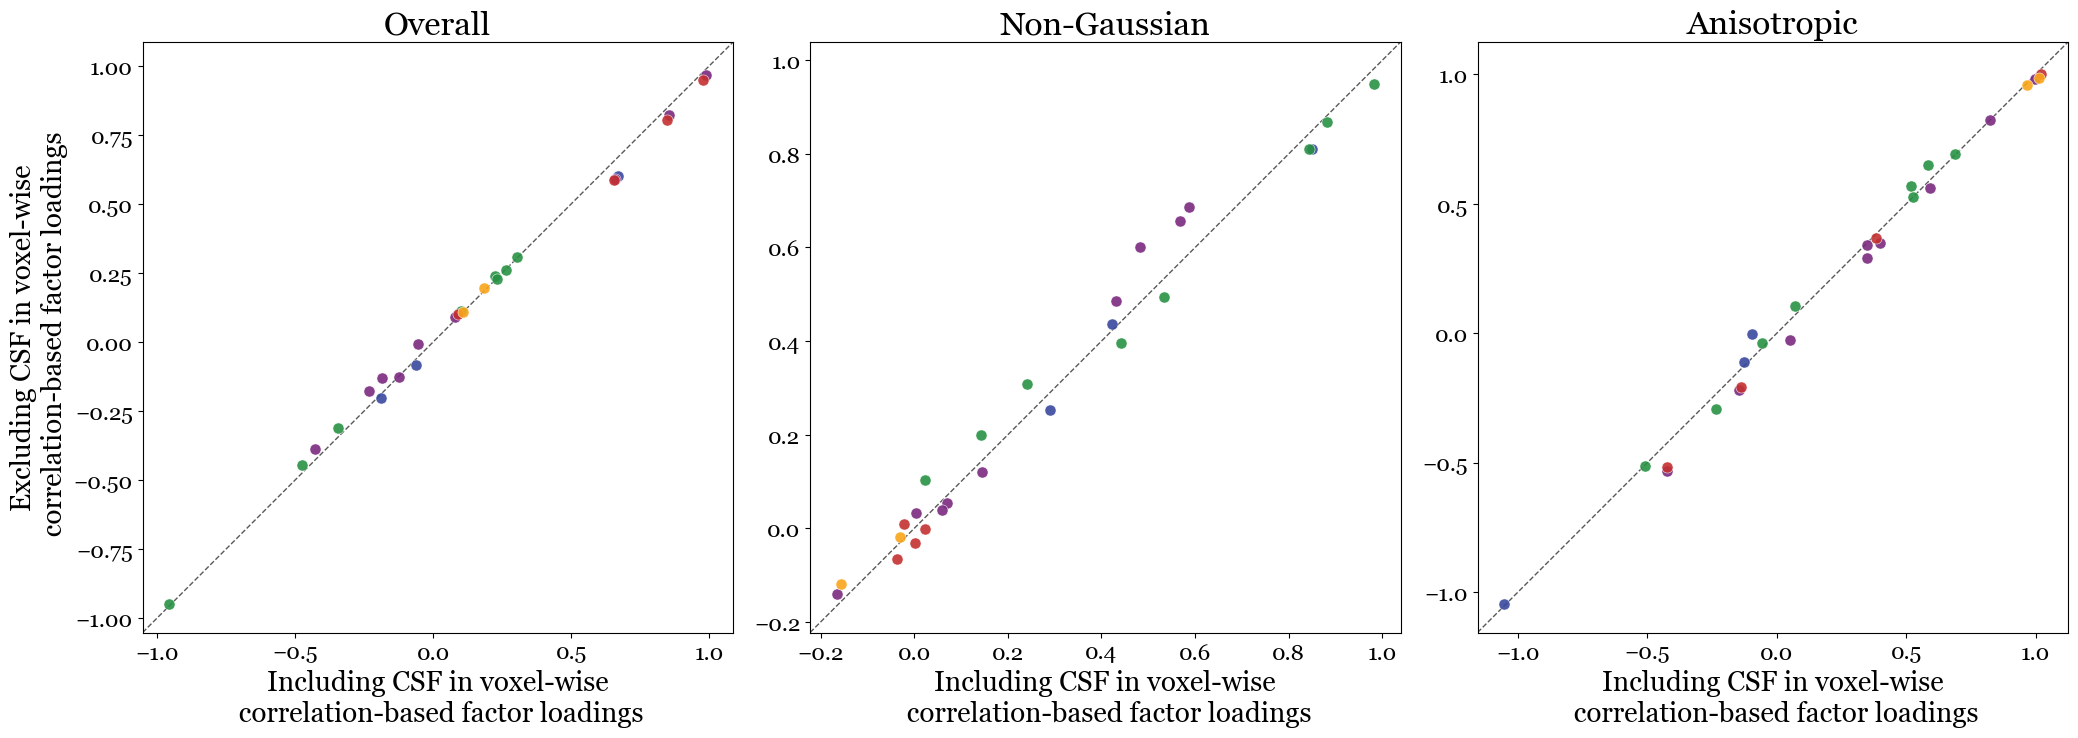

Saved: __PROJECT_ROOT__/derivatives/analysis/factor_analysis_voxelwise/figures/factors-3_all_with_csf_vs_no_csf_loadings_scatter.png
CSF alignment perm=[0, 1, 2], signs=[1, 1, 1]

factors-3: voxelwise (With CSF voxels) vs regionwise (all controls)
  Overall: r = 0.978
    voxelwise (With CSF voxels) top loadings: dki_ad (+0.989), dti_ad (+0.978), map_rtpp (-0.956)
    regionwise (aligned) top loadings: map_rtpp (-1.022), dki_ad (+1.006), dti_ad (+0.992)
  Non-Gaussian: r = 0.952
    voxelwise (With CSF voxels) top loadings: map_ng (+0.981), map_ngpar (+0.881), noddi_icvf (+0.849)
    regionwise (aligned) top loadings: map_ng (+0.913), map_ngperp (+0.859), noddi_icvf (+0.811)
  Anisotropic: r = 0.952
    voxelwise (With CSF voxels) top loadings: noddi_od (-1.052), dti_fa (+1.022), gqi_qa (+1.012)
    regionwise (aligned) top loadings: gqi_gfa (+1.017), noddi_od (-0.958), dti_fa (+0.876)


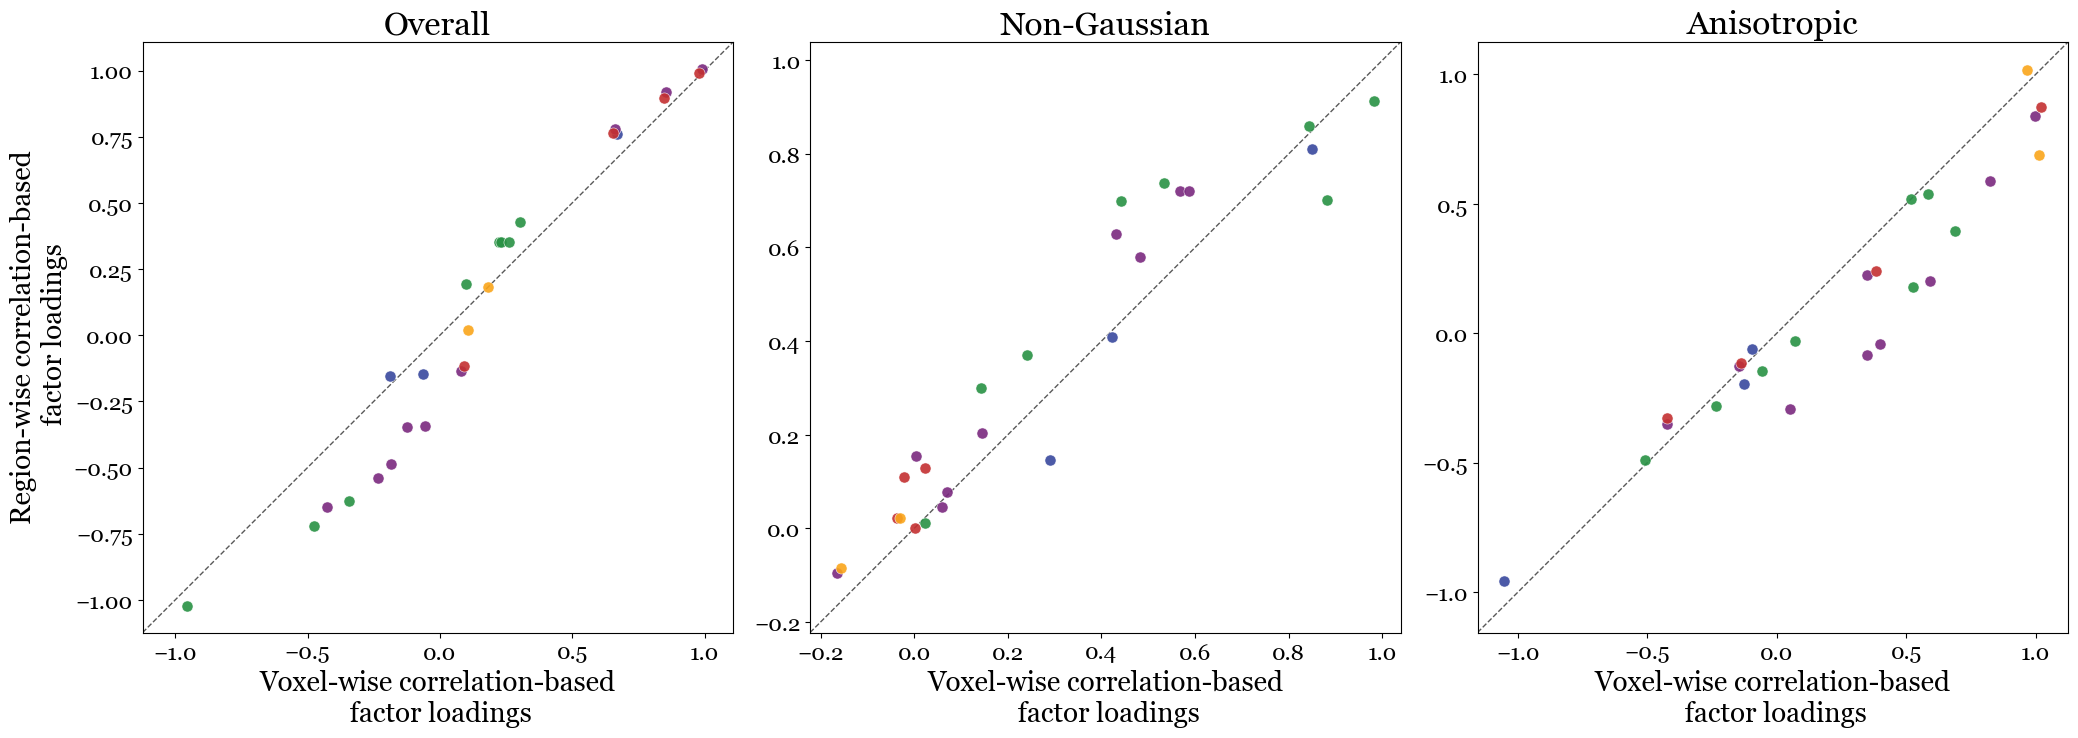

Saved: __PROJECT_ROOT__/derivatives/analysis/factor_analysis_voxelwise/figures/factors-3_voxelwise_with_csf_vs_regionwise_loadings_scatter.png
Voxelwise vs regionwise (with_csf) alignment perm=[2, 0, 1], signs=[1, 1, 1]

factors-3: voxelwise (Without CSF voxels) vs regionwise (all controls)
  Overall: r = 0.970
    voxelwise (Without CSF voxels) top loadings: dki_ad (+0.966), map_rtpp (-0.951), dti_ad (+0.949)
    regionwise (aligned) top loadings: map_rtpp (-1.022), dki_ad (+1.006), dti_ad (+0.992)
  Non-Gaussian: r = 0.957
    voxelwise (Without CSF voxels) top loadings: map_ng (+0.949), map_ngpar (+0.869), noddi_icvf (+0.811)
    regionwise (aligned) top loadings: map_ng (+0.913), map_ngperp (+0.859), noddi_icvf (+0.811)
  Anisotropic: r = 0.956
    voxelwise (Without CSF voxels) top loadings: noddi_od (-1.045), dti_fa (+1.003), gqi_qa (+0.986)
    regionwise (aligned) top loadings: gqi_gfa (+1.017), noddi_od (-0.958), dti_fa (+0.876)


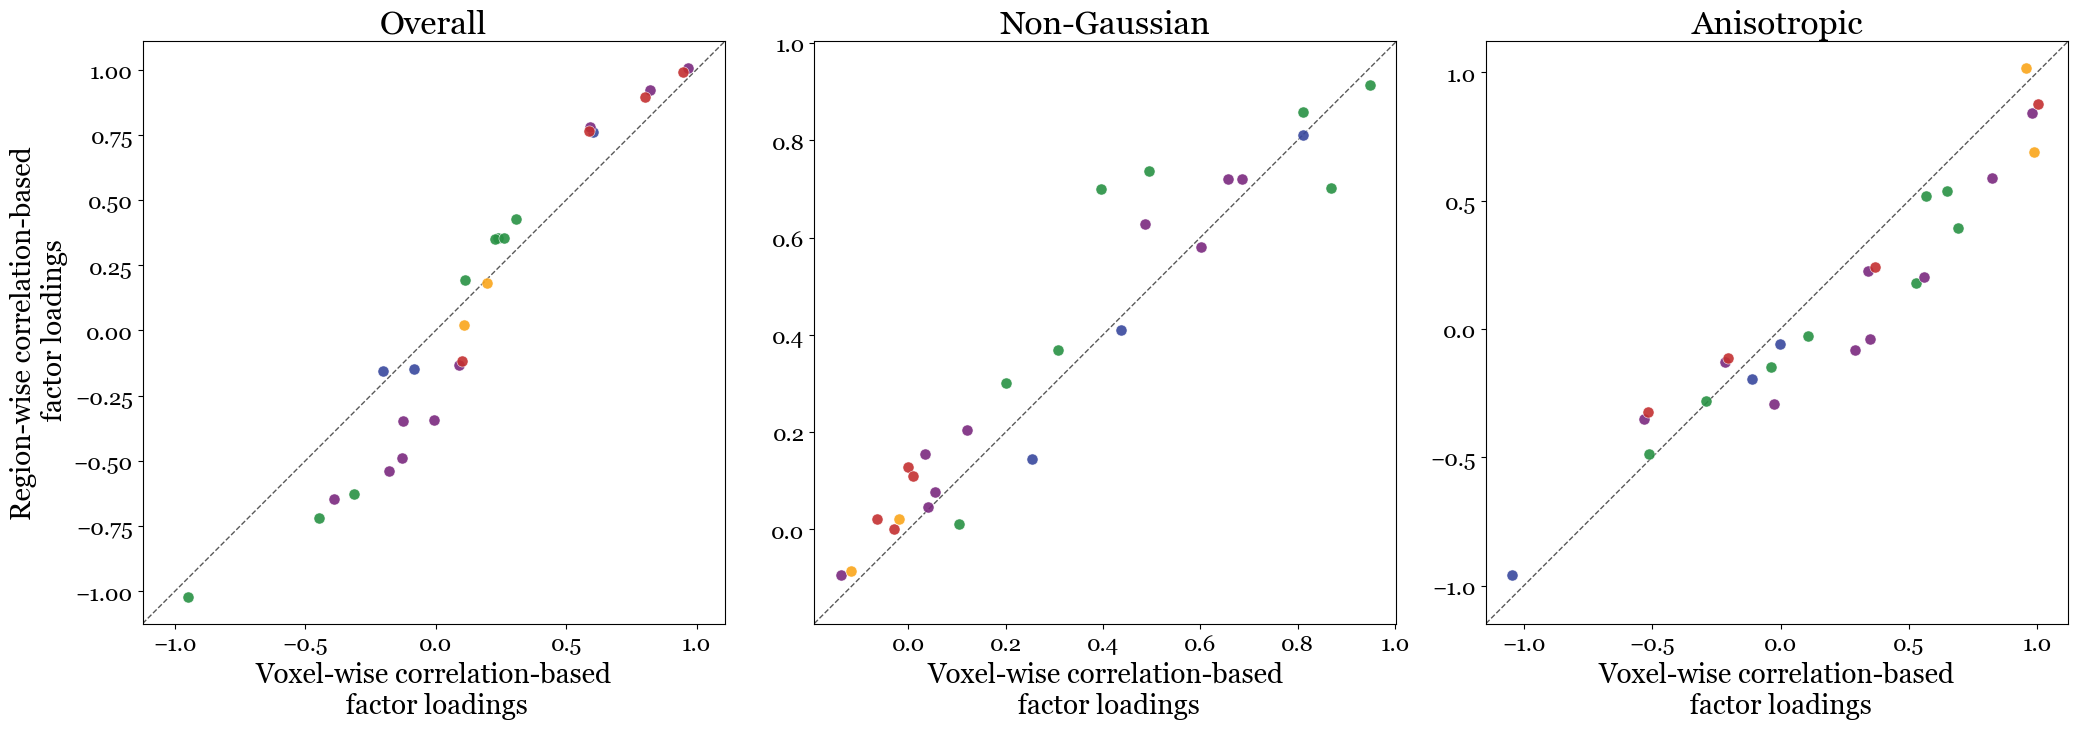

Saved: __PROJECT_ROOT__/derivatives/analysis/factor_analysis_voxelwise/figures/factors-3_voxelwise_no_csf_vs_regionwise_loadings_scatter.png
Voxelwise vs regionwise (no_csf) alignment perm=[2, 0, 1], signs=[1, 1, 1]

Group loading correlations (With CSF voxels):
  Overall:
    All controls vs HCP-YA: r = 0.986
    All controls vs HCP-Aging: r = 0.995
    All controls vs Penn controls: r = 0.981
    HCP-YA vs HCP-Aging: r = 0.974
    HCP-YA vs Penn controls: r = 0.967
    HCP-Aging vs Penn controls: r = 0.964
  Non-Gaussian:
    All controls vs HCP-YA: r = 0.969
    All controls vs HCP-Aging: r = 0.972
    All controls vs Penn controls: r = 0.790
    HCP-YA vs HCP-Aging: r = 0.887
    HCP-YA vs Penn controls: r = 0.897
    HCP-Aging vs Penn controls: r = 0.635
  Anisotropic:
    All controls vs HCP-YA: r = 0.990
    All controls vs HCP-Aging: r = 0.995
    All controls vs Penn controls: r = 0.927
    HCP-YA vs HCP-Aging: r = 0.976
    HCP-YA vs Penn controls: r = 0.944
    HCP-Aging vs 

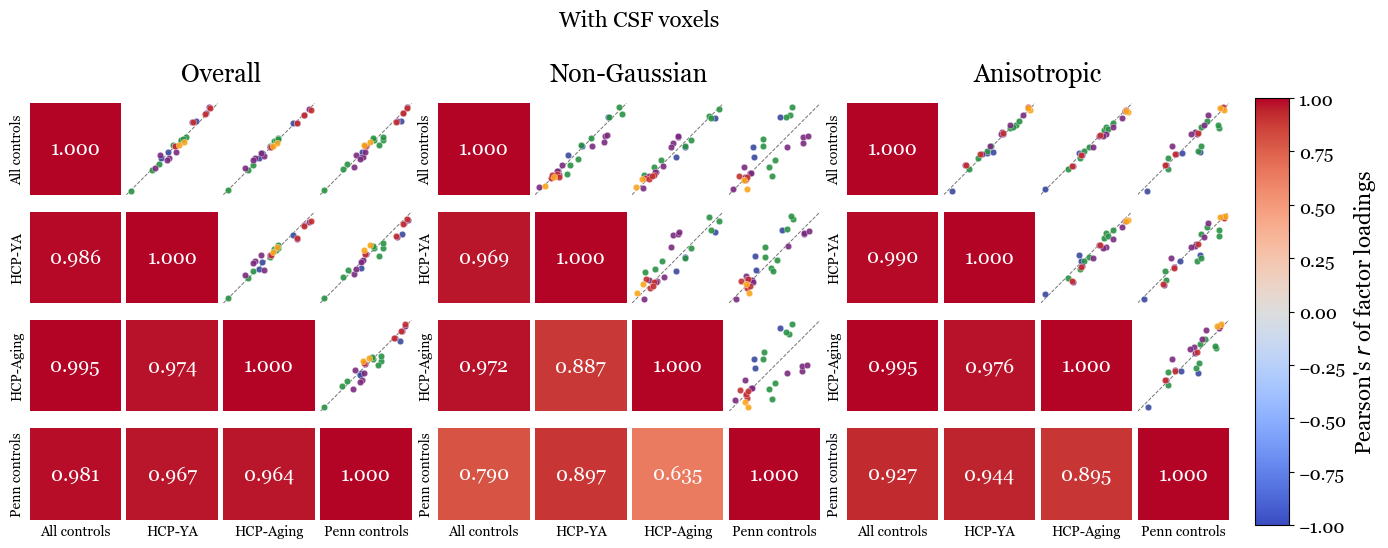

Saved: __PROJECT_ROOT__/derivatives/analysis/factor_analysis_voxelwise/figures/factors-3_group_loading_correlations_with_csf.png

Group loading correlations (Without CSF voxels):
  Overall:
    All controls vs HCP-YA: r = 0.987
    All controls vs HCP-Aging: r = 0.995
    All controls vs Penn controls: r = 0.986
    HCP-YA vs HCP-Aging: r = 0.976
    HCP-YA vs Penn controls: r = 0.970
    HCP-Aging vs Penn controls: r = 0.969
  Non-Gaussian:
    All controls vs HCP-YA: r = 0.978
    All controls vs HCP-Aging: r = 0.953
    All controls vs Penn controls: r = 0.878
    HCP-YA vs HCP-Aging: r = 0.874
    HCP-YA vs Penn controls: r = 0.943
    HCP-Aging vs Penn controls: r = 0.704
  Anisotropic:
    All controls vs HCP-YA: r = 0.989
    All controls vs HCP-Aging: r = 0.993
    All controls vs Penn controls: r = 0.955
    HCP-YA vs HCP-Aging: r = 0.973
    HCP-YA vs Penn controls: r = 0.962
    HCP-Aging vs Penn controls: r = 0.921


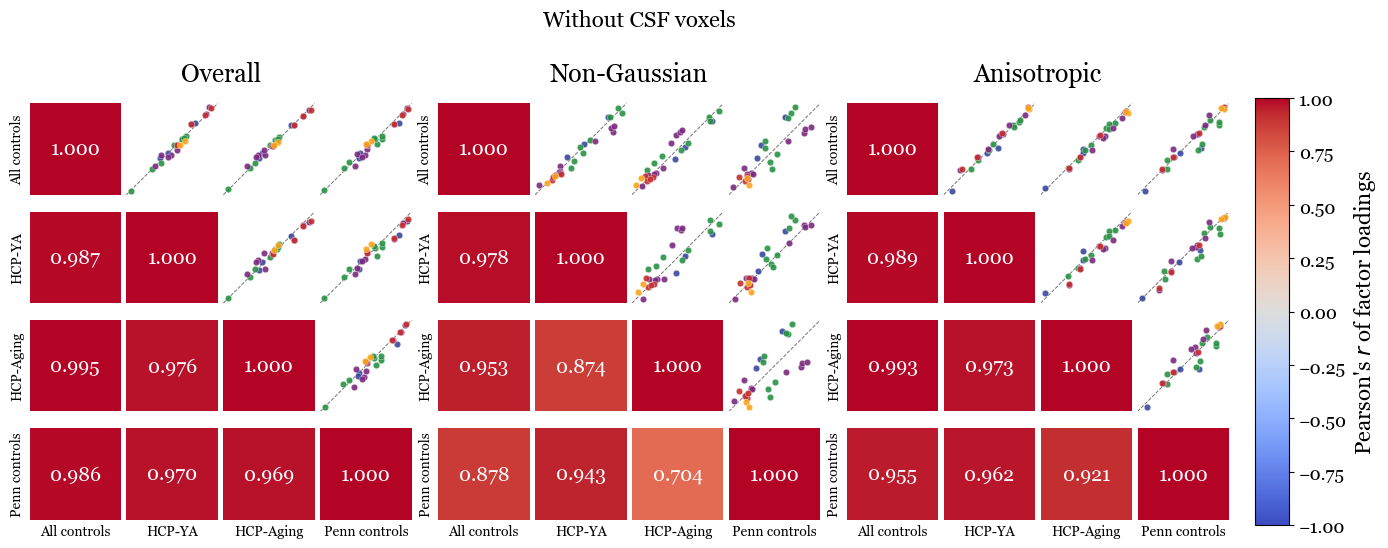

Saved: __PROJECT_ROOT__/derivatives/analysis/factor_analysis_voxelwise/figures/factors-3_group_loading_correlations_no_csf.png
factors-3: factor matching relative to all reference (per mask)

  Mask: With CSF voxels
    Reference Overall top loadings: dki_ad (+0.989), dti_ad (+0.978), map_rtpp (-0.956)
    Reference Non-Gaussian top loadings: map_ng (+0.981), map_ngpar (+0.881), noddi_icvf (+0.849)
    Reference Anisotropic top loadings: noddi_od (-1.052), dti_fa (+1.022), gqi_qa (+1.012)
    all            perm=[0, 1, 2] signs=[1, 1, 1]
    hcpya          perm=[0, 2, 1] signs=[1, 1, 1]  row_r=['0.990', '0.986', '0.969']
      aligned Overall top loadings: map_rtpp (-0.944), dti_ad (+0.907), dki_ad (+0.877)
      aligned Non-Gaussian top loadings: map_ngpar (+0.981), map_ng (+0.928), map_ngperp (+0.794)
      aligned Anisotropic top loadings: gqi_gfa (+0.989), noddi_od (-0.962), dki_fa (+0.955)
    hcpaging       perm=[0, 1, 2] signs=[1, 1, 1]  row_r=['0.995', '0.995', '0.972']
      a

In [25]:
# Bootstrap scalar column list from first factors-3 file
_ = load_loadings(loadings_path("all", "with_csf", "factors-3"), 3)
save_model_legend()
run_factor_comparison("factors-3", 3)


## factors-4


In [ ]:
run_factor_comparison("factors-4", 4)
